# Crop Yield Prediction

In [1]:
# --- Core Python & Data Handling ---
import os
import json
import warnings
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns


# --- Model Libraries ---
import joblib
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --- Misc ---
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset
df = pd.read_csv('data/Crop_Yield.csv')

In [3]:
df.columns

Index(['crop', 'year', 'season', 'state', 'area', 'production',
       'annual rainfall', 'yield'],
      dtype='object')

In [4]:
df['crop'].unique()

array(['Maize', 'Onion', 'Potato', 'Rice', 'Sugarcane', 'Wheat', 'Bajra',
       'Groundnut', 'Barley', 'Sunflower'], dtype=object)

In [5]:
df['season'] = df['season'].str.strip().str.lower().str.title()
df['state'] = df['state'].str.strip().str.lower().str.title()
df['crop'] = df['crop'].str.strip().str.lower().str.title()

In [6]:
# Standardizing crop names (keeping them simple)
crop_corrections = {
    'bajra': 'pearl_millet',
    'barley': 'barley',
    'groundnut': 'groundnut',
    'maize': 'maize',
    'onion': 'onion',
    'potato': 'potato',
    'rice': 'rice',
    'sugarcane': 'sugarcane',
    'sunflower': 'sunflower',
    'wheat': 'wheat'
}
df['crop'] = df['crop'].replace(crop_corrections)

In [7]:
print("Unique Seasons:", df['season'].unique())
print("Unique States:", df['state'].unique())
print("Unique Crops:", df['crop'].unique())

Unique Seasons: ['Kharif' 'Whole Year' 'Autumn' 'Summer' 'Winter' 'Rabi']
Unique States: ['Assam' 'Karnataka' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa' 'Kerala'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha' 'Bihar' 'Gujarat' 'Madhya Pradesh'
 'Maharashtra' 'Mizoram' 'Punjab' 'Uttar Pradesh' 'Haryana'
 'Himachal Pradesh' 'Tripura' 'Nagaland' 'Chhattisgarh' 'Uttarakhand'
 'Jharkhand' 'Delhi' 'Manipur' 'Jammu And Kashmir' 'Telangana'
 'Arunachal Pradesh' 'Sikkim']
Unique Crops: ['Maize' 'Onion' 'Potato' 'Rice' 'Sugarcane' 'Wheat' 'Bajra' 'Groundnut'
 'Barley' 'Sunflower']


### Visualization for crop and states 

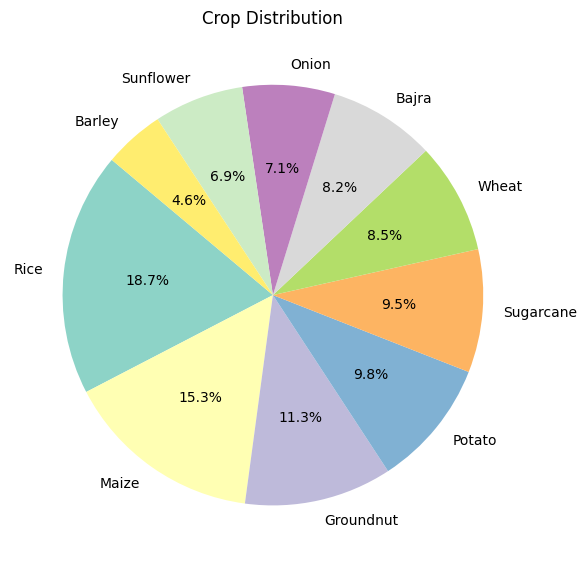

In [8]:
# Pie chart with Set3 color palette
plt.figure(figsize=(6,6))
colors = plt.cm.Set3(np.linspace(0, 1, df['crop'].nunique()))
df['crop'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title('Crop Distribution')
plt.ylabel('')  # Hide y-label for aesthetics
plt.tight_layout()
plt.show()


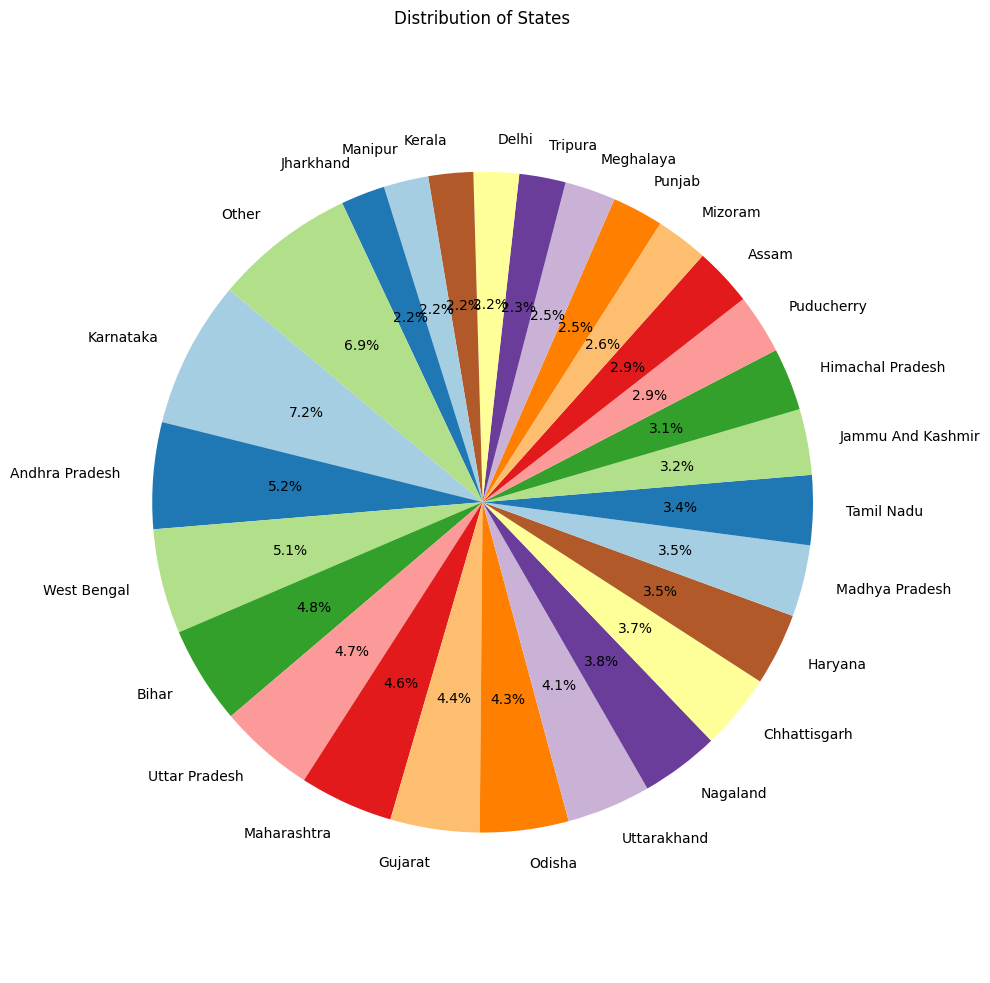

In [9]:
# Grouping less frequent states into "Other"
state_counts = df['state'].value_counts(normalize=True) * 100
threshold = 2  # Example: Any state with less than 2% frequency will be grouped as 'Other'
other_states = state_counts[state_counts < threshold].sum()
state_counts = state_counts[state_counts >= threshold]
state_counts['Other'] = other_states

# Plotting the pie chart with the new distribution
plt.figure(figsize=(10, 10))
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of States')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()


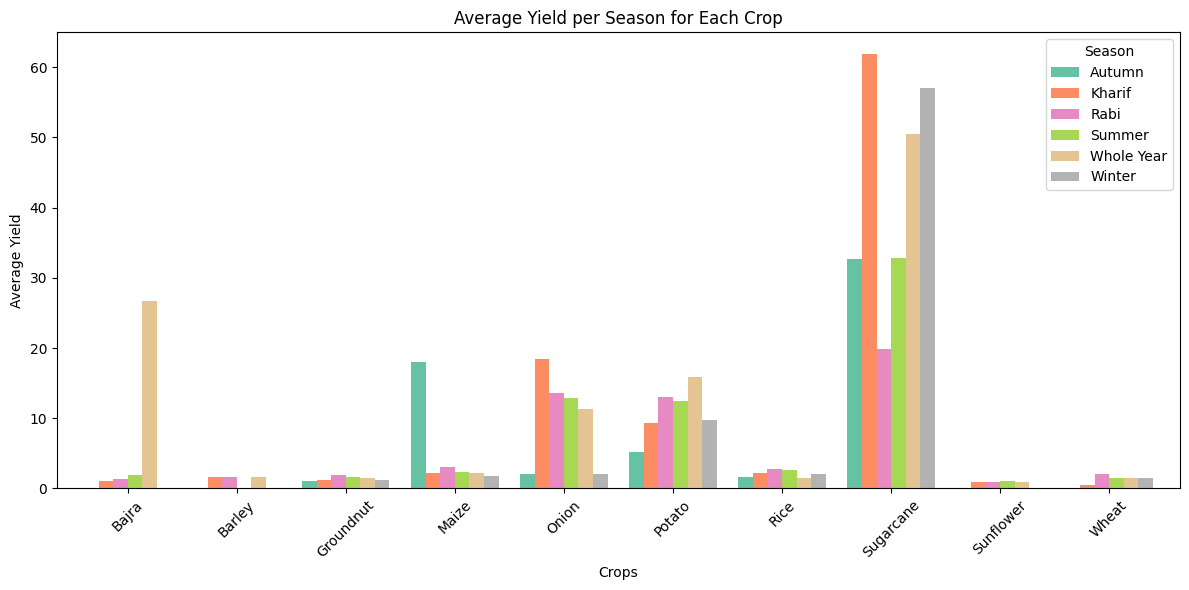

In [10]:
# Grouping by crop and season to calculate the average yield
avg_yield_season = df.groupby(['crop', 'season'])['yield'].mean().unstack().fillna(0)

# Plotting the average yield per season for each crop using a bar chart
avg_yield_season.plot(kind='bar', figsize=(12, 6), colormap='Set2', width=0.8)
plt.title('Average Yield per Season for Each Crop')
plt.xlabel('Crops')
plt.ylabel('Average Yield')
plt.xticks(rotation=45)
plt.yticks()  
plt.tight_layout()
plt.legend(title="Season")
plt.show()


### Feature Encoding

In [11]:
le_season = LabelEncoder()
le_state = LabelEncoder()
le_crop = LabelEncoder()

df['season_enc'] = le_season.fit_transform(df['season'])
df['state_enc'] = le_state.fit_transform(df['state'])
df['crop_enc'] = le_crop.fit_transform(df['crop'])

In [12]:
features = ['area', 'annual rainfall', 'season_enc', 'state_enc', 'crop_enc', 'year']
target = 'production'

X = df[features]
y = df[target]

### Split dataset into train and test

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [14]:
# Convert to DMatrix (required for xgb.cv)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define base parameters
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 1.0,
    'eval_metric': 'rmse'
}

# Perform Cross-Validation
cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,  # Higher value for better tuning
    nfold=5,  # More folds for better validation
    early_stopping_rounds=10,
    metrics='rmse',
    as_pandas=True,
    seed=42
)

In [15]:
# Best number of boosting rounds
best_num_boost_round = cv_results.shape[0]
print(f"✅ Best Boosting Rounds: {best_num_boost_round}")

✅ Best Boosting Rounds: 166


In [16]:
# Train final model with best rounds
final_model = xgb.train(params, dtrain, num_boost_round=best_num_boost_round)

# Predict on test data
y_pred = final_model.predict(dtest)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"\n📊 Model Evaluation:\n🔹 R² Score: {r2:.4f}\n🔹 Mean Squared Error: {mse:.2f}")



📊 Model Evaluation:
🔹 R² Score: 0.9738
🔹 Mean Squared Error: 2660490182438.83


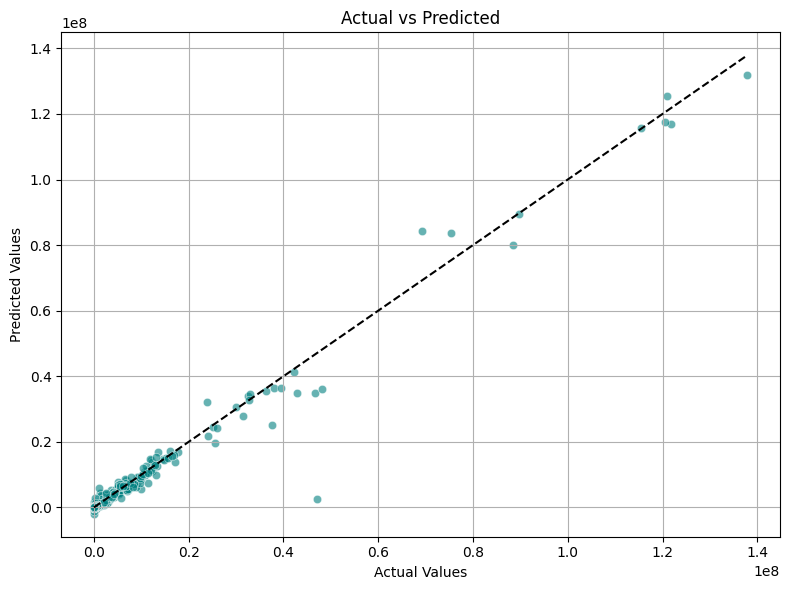

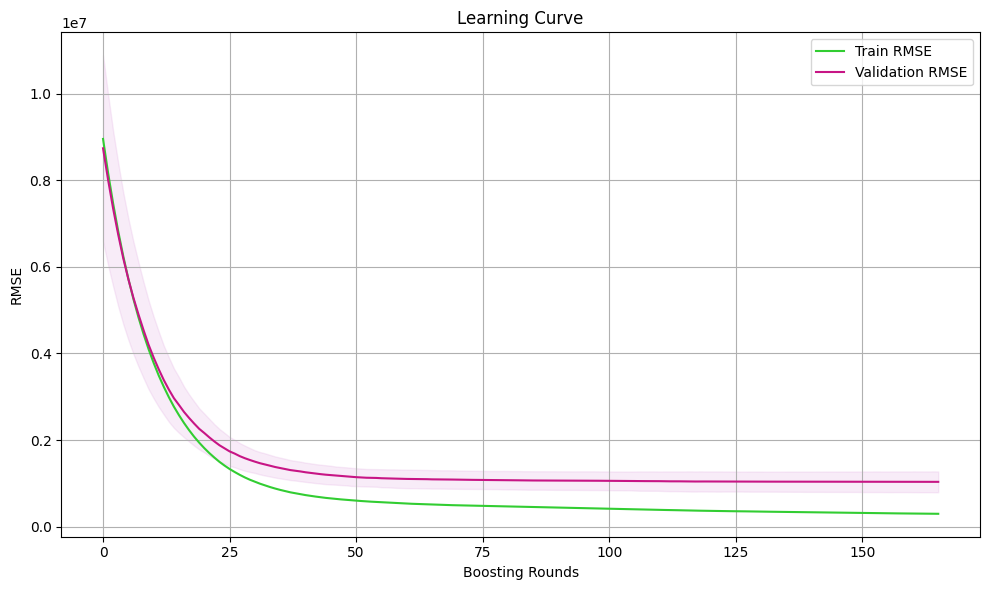

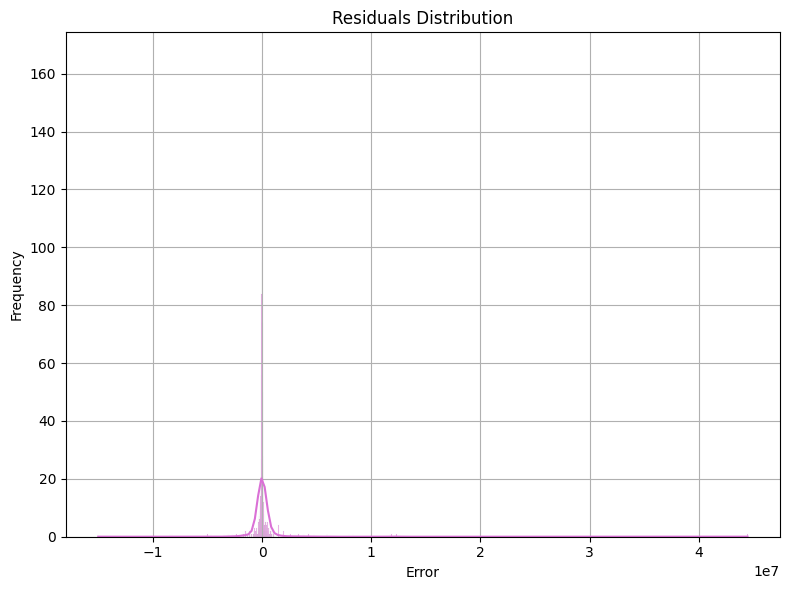

In [17]:
# Calculate residuals
residuals = y_test - y_pred

# 1️⃣ Crop Yield Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='teal', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='black')  # Reference line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2️⃣ Learning Curve using cross-validation RMSE
plt.figure(figsize=(10, 6))
plt.plot(cv_results['train-rmse-mean'], label='Train RMSE', color='limegreen')
plt.plot(cv_results['test-rmse-mean'], label='Validation RMSE', color='mediumvioletred')
plt.fill_between(
    range(len(cv_results)),
    cv_results['test-rmse-mean'] - cv_results['test-rmse-std'],
    cv_results['test-rmse-mean'] + cv_results['test-rmse-std'],
    alpha=0.2, color='plum'  # Shaded area = standard deviation
)
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3️⃣ Residuals Distribution Plot
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='orchid')  # kde=True for curve overlay
plt.title("Residuals Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    min_gain_to_split=0,  # Allow splits even with zero gain
    min_child_samples=1  # Reduce the minimum number of samples per leaf
)
lgb_model.fit(X_train, y_train)
lgb_y_pred = lgb_model.predict(X_test)

# Calculate evaluation metrics
lgb_r2 = r2_score(y_test, lgb_y_pred)
lgb_mse = mean_squared_error(y_test, lgb_y_pred)

# Print results
print(f'LightGBM R² Score: {lgb_r2:.4f}')
print(f'LightGBM Mean Squared Error: {lgb_mse:.4f}')


[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 5112, number of used features: 6
[LightGBM] [Info] Start training from score 1927768.918623
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [19]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
print(f'Random Forest R² Score: {rf_r2:.4f}')
print(f'Random Forest Mean Squared Error: {rf_mse:.4f}')

Random Forest R² Score: 0.9727
Random Forest Mean Squared Error: 2777093186984.8657


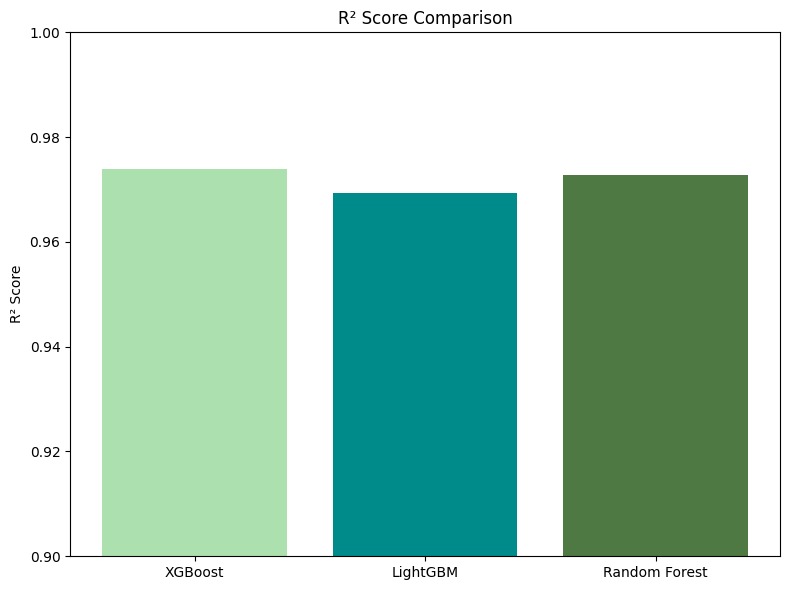

In [20]:
# Model performance metrics from variables
models = ['XGBoost', 'LightGBM', 'Random Forest']
r2_scores = [r2, lgb_r2, rf_r2]
# Define custom colors for the R² bars
colors = ['#ACE1AF', '#008B8B', '#4F7942']

# Create a single subplot for R² scores
fig, ax = plt.subplots(figsize=(8, 6))

# Bar chart for R² scores with different colors
ax.bar(models, r2_scores, color=colors)
ax.set_title('R² Score Comparison')
ax.set_ylabel('R² Score')
ax.set_ylim([0.9, 1])

# Show the plot
plt.tight_layout()
plt.show()

### Save Models 

In [21]:
# Save model in both .json and .pkl formats
joblib.dump(final_model, "models/xgboost_crop_production_model.pkl")  # Pickle format

# Save encoders and scaler
joblib.dump(le_season, "models/season_encoder.pkl")
joblib.dump(le_state, "models/state_encoder.pkl")
joblib.dump(le_crop, "models/crop_encoder.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("\n✅ Model & encoders saved successfully in 'models/' folder!")


✅ Model & encoders saved successfully in 'models/' folder!


### Testing 

In [22]:
# ✅ Load model and encoders
model = joblib.load('models/xgboost_crop_production_model.pkl')
le_season = joblib.load('models/season_encoder.pkl')
le_state = joblib.load('models/state_encoder.pkl')
le_crop = joblib.load('models/crop_encoder.pkl')
scaler = joblib.load('models/scaler.pkl')

# ✅ Load dataset and clean spaces
df = pd.read_csv('data/Crop_Yield.csv')
df['crop'] = df['crop'].str.strip()
df['season'] = df['season'].str.strip()
df['state'] = df['state'].str.strip()

# ✅ Unique crops list for FUT prediction
crops = le_crop.classes_

predictions = []

# ✅ Predict FUT 2026 production and compute yield
for crop in crops:
    crop_data = df[df['crop'] == crop]
    if crop_data.empty:
        continue

    # ✅ Calculate average rainfall & round it
    avg_rainfall = round(crop_data['annual rainfall'].mean(), 2)

    # ✅ Get most common season and state
    common_season = crop_data['season'].mode()[0].strip()
    common_state = crop_data['state'].mode()[0].strip()

    # ✅ Encode
    try:
        season_enc = le_season.transform([common_season])[0]
        state_enc = le_state.transform([common_state])[0]
        crop_enc = le_crop.transform([crop])[0]
    except ValueError as e:
        print(f"Skipping crop {crop} due to encoding error: {e}")
        continue

    # ✅ Predict for FUT 2026 with average area
    avg_area = crop_data['area'].mean()

    # ✅ Area unit check: If it's acres, convert to hectares (optional safety)
    avg_area_ha = avg_area  # Assuming area is already in hectares

    sample_features = np.array([[avg_area_ha, avg_rainfall, season_enc, state_enc, crop_enc, 2026]])
    scaled_features = scaler.transform(sample_features)

    # ✅ Convert to DMatrix for XGBoost prediction
    dtest = xgb.DMatrix(scaled_features)

    # ✅ Model prediction (assumed output in tons), convert to kilograms
    predicted_production_tons = model.predict(dtest)[0]
    predicted_production_kg = predicted_production_tons * 1000  # Convert tons to kg

    # ✅ Calculate Yield (kg/ha)
    if avg_area_ha > 0:
        predicted_yield = predicted_production_kg / avg_area_ha
    else:
        continue  # Skip crops with zero area to avoid division error

    # ✅ Ignore negative or unrealistic low yield values
    if predicted_yield > 500:  # Example threshold to filter very low yields
        predictions.append({
            'crop': crop,
            'yield': round(predicted_yield, 2),  # Final yield rounded
            'avg_rainfall': avg_rainfall,
            'season': common_season,
            'state': common_state
        })

# ✅ Remove duplicate crops (safety)
unique_predictions = {item['crop']: item for item in predictions}.values()

# ✅ Sort crops by yield
sorted_crops = sorted(unique_predictions, key=lambda x: x['yield'], reverse=True)

# ✅ Get Top 3 and Low 3 based on yield
top_crops = sorted_crops[:3]
low_crops = sorted_crops[-3:]

# ✅ Final JSON output
result = {
    "topCrops": top_crops,
    "lowCrops": low_crops
}

# ✅ Save to static folder for Flask / frontend
os.makedirs('static', exist_ok=True)
with open('static/predictions.json', 'w') as f:
    json.dump(result, f, indent=4)

print("✅ FUT 2026 Predictions with Yield saved to static/predictions.json")
print(json.dumps(result, indent=4))


Skipping crop Barley due to encoding error: y contains previously unseen labels: 'Jammu and Kashmir'
✅ FUT 2026 Predictions with Yield saved to static/predictions.json
{
    "topCrops": [
        {
            "crop": "Sugarcane",
            "yield": 67433.34,
            "avg_rainfall": 1560.09,
            "season": "Whole Year",
            "state": "Manipur"
        },
        {
            "crop": "Onion",
            "yield": 18543.6,
            "avg_rainfall": 1220.36,
            "season": "Whole Year",
            "state": "Karnataka"
        },
        {
            "crop": "Potato",
            "yield": 16373.81,
            "avg_rainfall": 1485.87,
            "season": "Whole Year",
            "state": "Karnataka"
        }
    ],
    "lowCrops": [
        {
            "crop": "Groundnut",
            "yield": 2861.1,
            "avg_rainfall": 1410.88,
            "season": "Kharif",
            "state": "Odisha"
        },
        {
            "crop": "Bajra",
    

# Rainfall Forecast

In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import warnings 
warnings.filterwarnings('ignore') 

In [24]:
# ✅ Load Rainfall Dataset (Assuming your rainfall.csv)
rainfall_df = pd.read_csv('data/Rainfall.csv')

In [25]:
rainfall_df.columns

Index(['state', 'year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG',
       'SEP', 'OCT', 'NOV', 'DEC', 'annual rainfall', 'JF', 'MAM', 'JJAS',
       'OND'],
      dtype='object')

In [26]:
# ✅ Check for NaN values and fill if necessary
rainfall_df.fillna(rainfall_df.mean(numeric_only=True), inplace=True)

### Feature Encoding

In [27]:
# ✅ Features & Target
features = ['year', 'JF', 'MAM', 'JJAS', 'OND']
target = 'annual rainfall'

X = rainfall_df[features]
y = rainfall_df[target]

### Split dataset into train and test

In [28]:
# ✅ Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# ✅ Train Rainfall Prediction Model (RandomForest)
rainfall_model = RandomForestRegressor(n_estimators=100, random_state=42)
rainfall_model.fit(X_train, y_train)

# ✅ Predict and Evaluate
y_pred = rainfall_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"✅ Rainfall Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}\n")

✅ Rainfall Model Performance:
R² Score: 0.9793
MSE: 19786.36



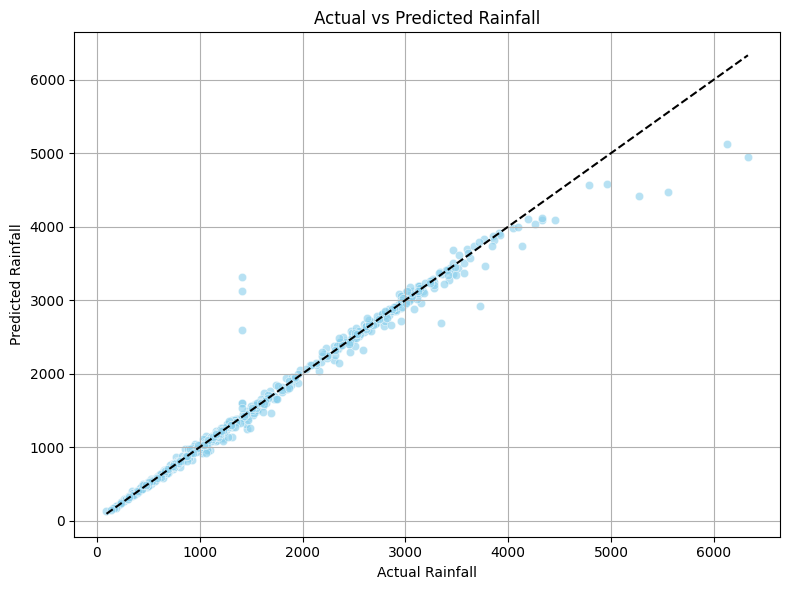

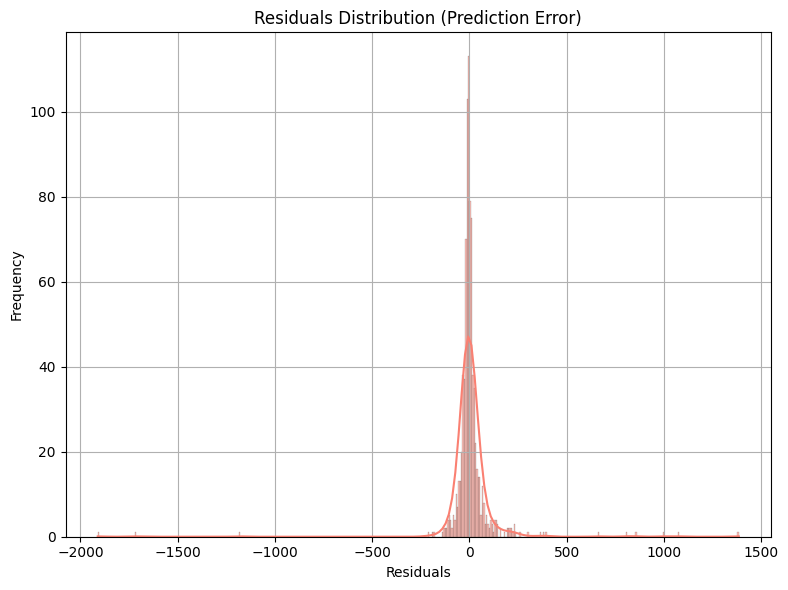

In [30]:
# Calculate residuals
residuals = y_test - y_pred

# 1️⃣ Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='skyblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='black')  # Diagonal reference line
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2️⃣ Residuals Distribution Plot
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='salmon')  # Histogram with KDE overlay
plt.title("Residuals Distribution (Prediction Error)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()



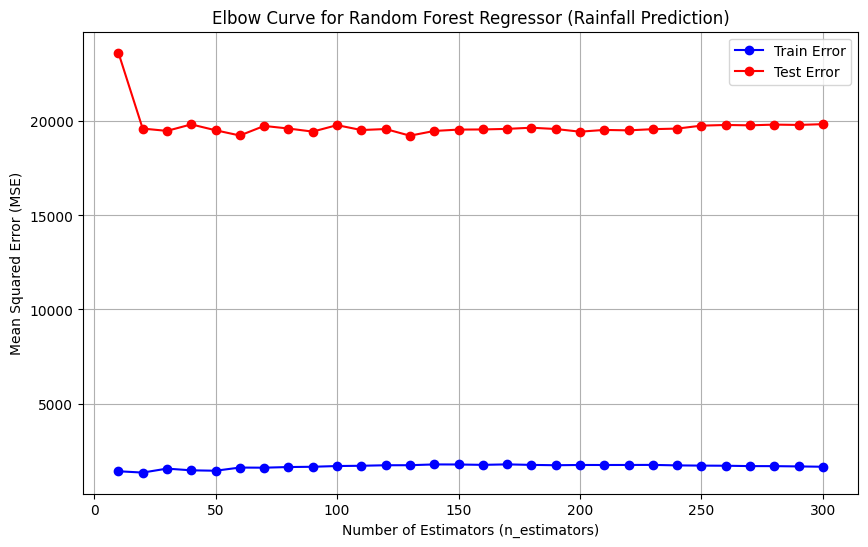

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Range of n_estimators to test
n_estimators_range = range(10, 301, 10)
train_errors = []
test_errors = []

# Train and evaluate the model for each n_estimators value
for n_estimators in n_estimators_range:
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    
    # Calculate predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate the Mean Squared Error (MSE) for both train and test
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, label='Train Error', color='blue', marker='o')
plt.plot(n_estimators_range, test_errors, label='Test Error', color='red', marker='o')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Elbow Curve for Random Forest Regressor (Rainfall Prediction)')
plt.legend()
plt.grid(True)
plt.show()


### Save Models 

In [32]:
# ✅ Save the model
joblib.dump(rainfall_model, 'models/rainfall_forecast_model.pkl')
print("✅ Rainfall Model Saved Successfully")

✅ Rainfall Model Saved Successfully


### Testing 

In [33]:
# ✅ Load the trained rainfall model
forecast_model = joblib.load('models/rainfall_forecast_model.pkl')

# ✅ Create future year data (2026) with seasonal averages (replace with realistic estimates if available)
future_data = pd.DataFrame({
    'year': [2026],
    'JF': [60],     # Example value
    'MAM': [120],   # Example value
    'JJAS': [800],  # Example value
    'OND': [250]    # Example value
})

# ✅ Predict annual rainfall for 2026
predicted_rainfall = forecast_model.predict(future_data)[0]

print(f"\n🌧️ Forecasted Annual Rainfall for 2026: {predicted_rainfall:.2f} mm")

# ✅ Simple Drought Check (You can set threshold as per your logic)
if predicted_rainfall < 800:
    print("🚨 Drought Alert: Rainfall prediction is low for 2026.")
else:
    print("✅ No Drought: Rainfall prediction looks good for 2026.")


🌧️ Forecasted Annual Rainfall for 2026: 1229.85 mm
✅ No Drought: Rainfall prediction looks good for 2026.


In [34]:
# ✅ Load Rainfall Dataset and Model
rainfall_df = pd.read_csv('data/Cleaned_Rainfall.csv')
rainfall_df.fillna(rainfall_df.mean(numeric_only=True), inplace=True)
rainfall_model = joblib.load('models/rainfall_forecast_model.pkl')

# ✅ Prepare features for each state for 2026 (Use last known seasonality values)
states = rainfall_df['state'].unique()
last_season_avg = rainfall_df.groupby('state')[['JF', 'MAM', 'JJAS', 'OND']].mean().reset_index()

future_data = pd.DataFrame({
    'state': states,
    'year': 2026
})
future_data = future_data.merge(last_season_avg, on='state', how='left')

# ✅ Predict annual rainfall for 2026
X_future = future_data[['year', 'JF', 'MAM', 'JJAS', 'OND']]
future_data['annual_rainfall_predicted'] = rainfall_model.predict(X_future)

# ✅ Determine Drought Status (threshold < 800 mm for drought)
future_data['Drought Status'] = future_data['annual_rainfall_predicted'].apply(
    lambda x: '🚨 Drought' if x < 800 else '✅ No Drought'
)

# ✅ Display Forecasted Data
print("\n🌾 State-wise Rainfall Forecast & Drought Status for 2026:")
print(future_data[['state', 'annual_rainfall_predicted', 'Drought Status']])



🌾 State-wise Rainfall Forecast & Drought Status for 2026:
                  state  annual_rainfall_predicted Drought Status
0   Andaman and Nicobar                   2909.588   ✅ No Drought
1     Arunachal Pradesh                   3375.136   ✅ No Drought
2                 Assam                   2618.186   ✅ No Drought
3              Nagaland                   2419.089   ✅ No Drought
4           West Bengal                   2142.486   ✅ No Drought
5                Odisha                   1480.559   ✅ No Drought
6         Uttar Pradesh                    894.486   ✅ No Drought
7           Uttarakhand                   1429.392   ✅ No Drought
8               Haryana                    528.154      🚨 Drought
9                Punjab                    569.809      🚨 Drought
10     Himachal Pradesh                   1199.220   ✅ No Drought
11    Jammu and Kashmir                   1157.926   ✅ No Drought
12            Rajasthan                    486.668      🚨 Drought
13       Madhya P

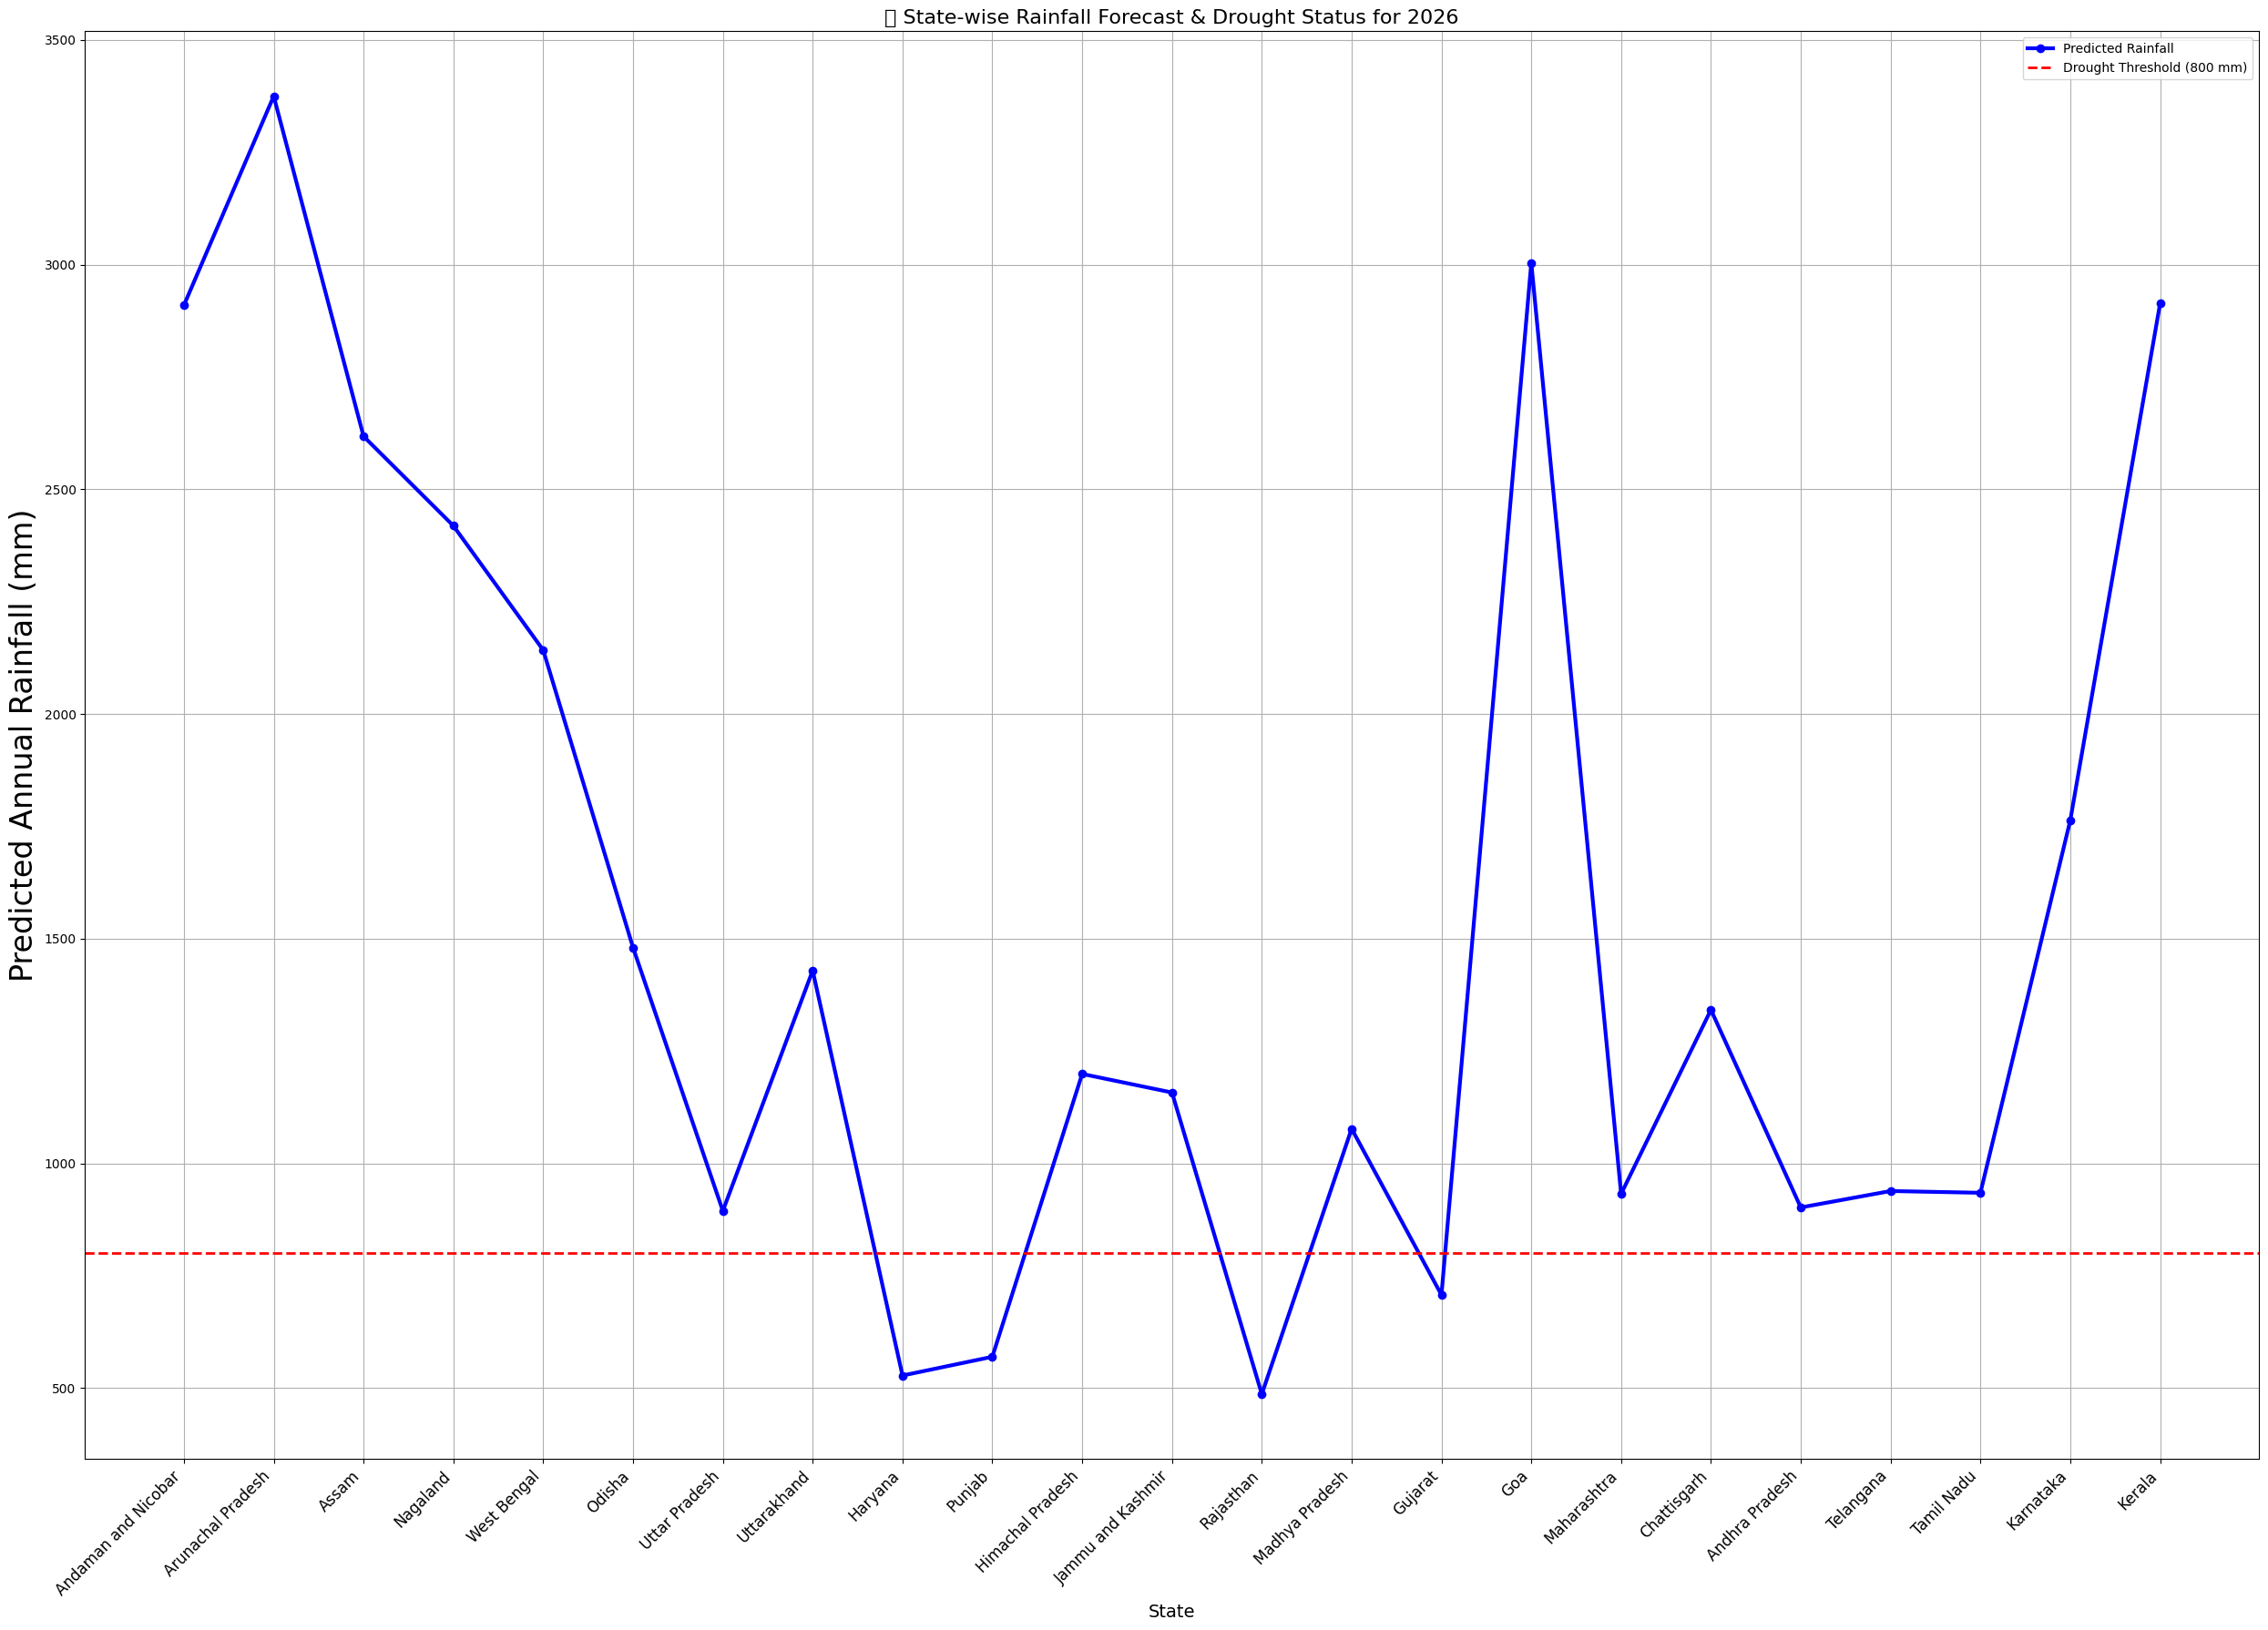

In [35]:
plt.figure(figsize=(25, 18))
plt.plot(future_data['state'], future_data['annual_rainfall_predicted'], 
         marker='o', color='blue', linewidth=3, label='Predicted Rainfall')

plt.axhline(800, color='red', linestyle='--', linewidth=2, label='Drought Threshold (800 mm)')
plt.xlabel('State', fontsize=14)
plt.ylabel('Predicted Annual Rainfall (mm)', fontsize=24)
plt.title('🌧️ State-wise Rainfall Forecast & Drought Status for 2026', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
